# Full-reveal fast path — download sweep

Four groups, fixed cable profile (20 Mbps, 20 ms), 1 KB upload, sent side always partially redacted.
Only the recv side differs:

- `mpc_redact_recv`  — MPC mode, recv partially redacted (ZK path on recv)
- `mpc_reveal_recv`  — MPC mode, recv fully revealed (fast path fires)
- `proxy_redact_recv` — Proxy mode, recv partially redacted
- `proxy_reveal_recv` — Proxy mode, recv fully revealed (fast path fires)


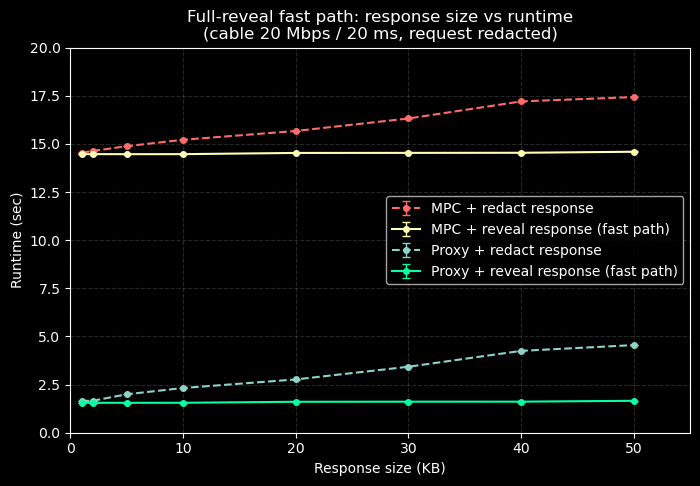

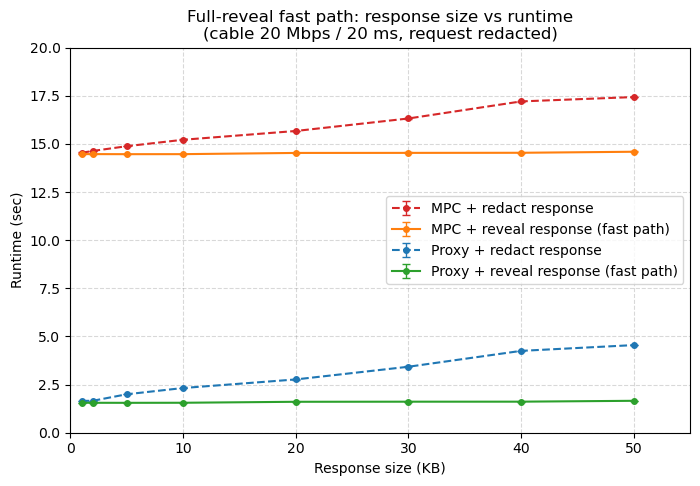

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

CSV = "metrics_fast_reveal_download.csv"
GROUPS = [
    ("mpc_redact_recv",   "MPC + redact response"),
    ("mpc_reveal_recv",   "MPC + reveal response (fast path)"),
    ("proxy_redact_recv", "Proxy + redact response"),
    ("proxy_reveal_recv", "Proxy + reveal response (fast path)"),
]

def style(dark):
    if dark:
        plt.style.use("dark_background")
        return {
            "mpc_redact_recv":   ("#ff6b6b", "--"),
            "mpc_reveal_recv":   ("#feffb3", "-"),
            "proxy_redact_recv": ("#8dd3c7", "--"),
            "proxy_reveal_recv": ("#06ffa5", "-"),
        }
    else:
        plt.style.use("default")
        return {
            "mpc_redact_recv":   ("#d62728", "--"),
            "mpc_reveal_recv":   ("#ff7f0e", "-"),
            "proxy_redact_recv": ("#1f77b4", "--"),
            "proxy_reveal_recv": ("#2ca02c", "-"),
        }

for dark in [True, False]:
    palette = style(dark)
    df = pd.read_csv(CSV)
    df = df[df["group"].isin([g for g, _ in GROUPS])]

    fig, ax = plt.subplots(figsize=(8, 5))
    for group, label in GROUPS:
        sub = df[df["group"] == group]
        agg = sub.groupby("download_size")["time_total"].agg(["mean", "std"]).reset_index()
        agg["std"] = agg["std"].fillna(0)
        color, ls = palette[group]
        ax.errorbar(
            agg["download_size"] / 1024.0,
            agg["mean"] / 1000.0,
            yerr=agg["std"] / 1000.0,
            label=label,
            color=color,
            linestyle=ls,
            capsize=3,
            capthick=1,
            elinewidth=1,
            marker="o",
            markersize=4,
        )

    ax.set_xlabel("Response size (KB)")
    ax.set_ylabel("Runtime (sec)")
    ax.set_title("Full-reveal fast path: response size vs runtime\n(cable 20 Mbps / 20 ms, request redacted)")
    ax.set_xlim(0, 55)
    ax.set_ylim(0, 20)
    ax.grid(True, linestyle="--", color="gray", alpha=0.3)
    ax.legend(loc="center right")

    out = "download_dark.svg" if dark else "download_light.svg"
    plt.savefig(out, bbox_inches="tight")
    plt.show()


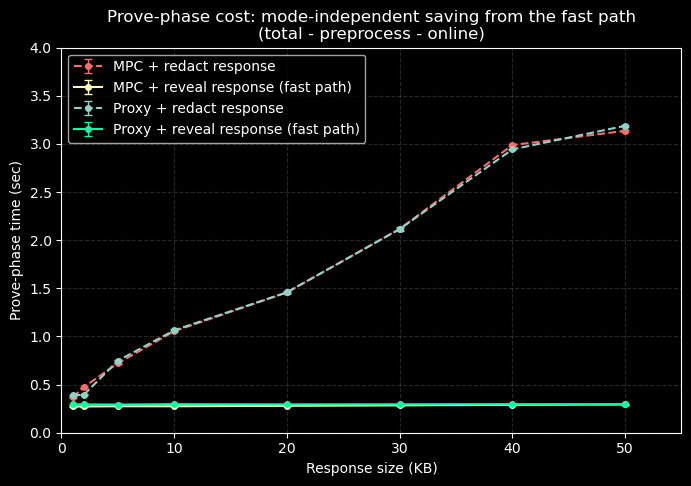

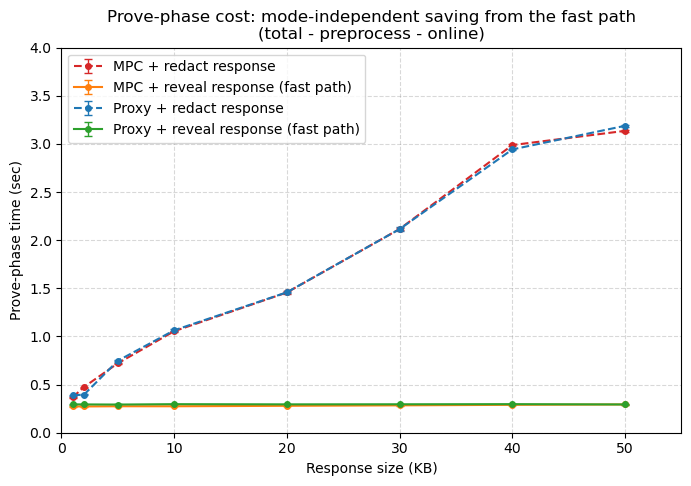

In [2]:
# Prove-phase cost = time_total - time_preprocess - time_online
# Isolates the phase the fast path actually affects: ZK authentication of the recv plaintext.
# Expected: redact curves grow with response size; reveal curves stay flat.
# The saving is mode-independent.
import pandas as pd
import matplotlib.pyplot as plt

CSV = "metrics_fast_reveal_download.csv"
GROUPS = [
    ("mpc_redact_recv",   "MPC + redact response"),
    ("mpc_reveal_recv",   "MPC + reveal response (fast path)"),
    ("proxy_redact_recv", "Proxy + redact response"),
    ("proxy_reveal_recv", "Proxy + reveal response (fast path)"),
]

def style(dark):
    if dark:
        plt.style.use("dark_background")
        return {
            "mpc_redact_recv":   ("#ff6b6b", "--"),
            "mpc_reveal_recv":   ("#feffb3", "-"),
            "proxy_redact_recv": ("#8dd3c7", "--"),
            "proxy_reveal_recv": ("#06ffa5", "-"),
        }
    else:
        plt.style.use("default")
        return {
            "mpc_redact_recv":   ("#d62728", "--"),
            "mpc_reveal_recv":   ("#ff7f0e", "-"),
            "proxy_redact_recv": ("#1f77b4", "--"),
            "proxy_reveal_recv": ("#2ca02c", "-"),
        }

for dark in [True, False]:
    palette = style(dark)
    df = pd.read_csv(CSV)
    df = df[df["group"].isin([g for g, _ in GROUPS])].copy()
    df["time_prove"] = df["time_total"] - df["time_preprocess"] - df["time_online"]

    fig, ax = plt.subplots(figsize=(8, 5))
    for group, label in GROUPS:
        sub = df[df["group"] == group]
        agg = sub.groupby("download_size")["time_prove"].agg(["mean", "std"]).reset_index()
        agg["std"] = agg["std"].fillna(0)
        color, ls = palette[group]
        ax.errorbar(
            agg["download_size"] / 1024.0,
            agg["mean"] / 1000.0,
            yerr=agg["std"] / 1000.0,
            label=label,
            color=color,
            linestyle=ls,
            capsize=3,
            capthick=1,
            elinewidth=1,
            marker="o",
            markersize=4,
        )

    ax.set_xlabel("Response size (KB)")
    ax.set_ylabel("Prove-phase time (sec)")
    ax.set_title("Prove-phase cost: mode-independent saving from the fast path\n(total - preprocess - online)")
    ax.set_xlim(0, 55)
    ax.set_ylim(0, 4)
    ax.grid(True, linestyle="--", color="gray", alpha=0.3)
    ax.legend(loc="upper left")

    out = "prove_dark.svg" if dark else "prove_light.svg"
    plt.savefig(out, bbox_inches="tight")
    plt.show()
